<a href="https://colab.research.google.com/github/Aryan-Kochhar/rl-lab-da1/blob/main/Aryan_DA1_RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q-Learning Based Dynamic Traffic Signal Control
**Digital Assignment 1**

Aryan Kochhar | 23BAI1533

In [12]:
import random
import json
import numpy as np
import matplotlib.pyplot as plt
random.seed(7)
np.random.seed(7)
LANES = ["N", "S", "E", "W"]
PHASES = ["A1", "A2", "A3", "A4"]

## 1. States

every lane's queue has is bucketed in three lvls light (25%) / moderate (60%) / high (>60)

waiting is two levels low (40%) and high (>40%) of capacity

In [13]:
def bucket_queue(n, cap):
    if n <= cap * 0.25:
        return 0
    elif n <= cap * 0.6:
        return 1
    return 2
def bucket_wait(avg_wait, cap):
    return 0 if avg_wait <= cap * 0.4 else 1

## 2. Environment (Junction)
State: (queue_N, queue_S, queue_E, queue_W, wait_level, current_phase)

Actions: A1 (N-S green), A2 (E-W green) serve 4 vehicles/step; A3 (N-S yellow), A4 (E-W yellow) serve 2 vehicles/step.

Reward: `R = w1*T - w2*W - w3*Q - w4*C - w5*S`

In [14]:
class Junction:
    LANE_CAP = 14
    SERVICE_GREEN = 4
    SERVICE_YELLOW = 2
    CONGESTION_CUTOFF = 0.7 # congested if above 70% of total capacity
    def __init__(self, arrival_rates=None):
        self.arrival_rates = arrival_rates or {"N": 0.35, "S": 0.35, "E": 0.3, "W": 0.3}
        self.reset()
    def reset(self): #starting phase A1
        self.queues = {l: 0 for l in LANES}
        self.phase = "A1"
        return self._state()
    def _state(self):
        avg_wait = self._waiting_lane_load()
        # get waiting load by avg of not moving lane
        return (
            #add vehicles in queue,
            bucket_queue(self.queues["N"], self.LANE_CAP),
            bucket_queue(self.queues["S"], self.LANE_CAP),
            bucket_queue(self.queues["E"], self.LANE_CAP),
            bucket_queue(self.queues["W"], self.LANE_CAP),
            bucket_wait(avg_wait, self.LANE_CAP), #high or low
            PHASES.index(self.phase), #phase of lane
        )
    def _waiting_lane_load(self):
        served = self._served_lanes(self.phase)[0]
        idle = [l for l in LANES if l not in served] #not moving lane
        return sum(self.queues[l] for l in idle) / 2.0 #idle's avg

    @staticmethod #doesnt use self
    def _served_lanes(phase):
        if phase == "A1":
            return ["N", "S"], Junction.SERVICE_GREEN
        if phase == "A2":
            return ["E", "W"], Junction.SERVICE_GREEN
        if phase == "A3":
            return ["N", "S"], Junction.SERVICE_YELLOW
        return ["E", "W"], Junction.SERVICE_YELLOW

    def step(self, action, weights):
        # random arrivals
        for l in LANES:
            if random.random() < self.arrival_rates[l]:
                self.queues[l] = min(self.queues[l] + random.choice([1, 1, 2]), self.LANE_CAP)
        # departures, gets which lane is chosen and its rate
        served_lanes, rate = self._served_lanes(action)
        throughput = 0
        for l in served_lanes:
            cleared = min(self.queues[l], rate)
            self.queues[l] -= cleared
            throughput += cleared

        #total_queue = Q, waiting_load = W, congested = C, switched = S
        total_queue = sum(self.queues.values()) #all lanes
        waiting_load = sum(self.queues[l] for l in LANES if l not in served_lanes)
        congested = int(total_queue > self.CONGESTION_CUTOFF * (self.LANE_CAP * 4))
        switched = int(action != self.phase)

        reward = ( weights["w1"] * throughput- weights["w2"]
            * waiting_load - weights["w3"] * total_queue-
            weights["w4"] * congested - weights["w5"] * switched)

        #R = 1.2·T − 1.0·W − 0.3·Q − 8.0·C − 5.0
        #throughput adds reward and everything else subtracts.

        #update and return
        self.phase = action #change phase
        info = {
            "throughput": throughput,
            "waiting": waiting_load,
            "queue": total_queue,
            "congested": congested,
            "switched": switched,
        }
        return self._state(), reward, info

##3. Q learning agent

Update rule: `Q(s,a) <- Q(s,a) + alpha * [r + gamma * max_a' Q(s',a') - Q(s,a)]`

In [15]:
class QAgent:
    def __init__(self, actions=PHASES, alpha=0.15, gamma=0.95,
                 eps_start=1.0, eps_min=0.05, eps_decay=0.985):
        self.actions = actions
        self.alpha, self.gamma = alpha, gamma
        self.eps, self.eps_min, self.eps_decay = eps_start, eps_min, eps_decay
        self.Q = {}

    def _row(self, s): #row value of q table [0,0,0,0]
        return self.Q.setdefault(s, np.zeros(len(self.actions)))

    def act(self, s): #using epsil greedy
        if random.random() < self.eps: #explre
            return random.choice(self.actions)
        return self.actions[int(np.argmax(self._row(s)))] #exploit

    def learn(self, s, a, r, s_next): #ql update
        row = self._row(s)
        idx = self.actions.index(a) #best action's index
        best_next =  np.max(self._row(s_next))
        row[idx] += self.alpha * (r + self.gamma *best_next - row[idx])

    def decay(self):
        self.eps = max(self.eps_min, self.eps * self.eps_decay)

##4. Training

In [16]:
WEIGHTS = {"w1": 1.2, "w2": 1.0, "w3": 0.3, "w4": 8.0, "w5": 5.0}
EPISODES = 400
STEPS_PER_EPISODE = 60
def train():
    env = Junction() #default traffic arrival rate
    agent = QAgent() #fresh q table, empty with full exploration
    reward_history = [] #reward per ep for graph
    for ep in range(EPISODES):
        s = env.reset() #empty queue
        ep_reward = 0
        for _ in range(STEPS_PER_EPISODE):
            a = agent.act(s) #pick phase e-greedy
            s_next, r, _ = env.step(a, WEIGHTS)
            agent.learn(s, a, r, s_next) #q val for it
            s = s_next #go next state
            ep_reward += r #add step's reward to episode's total
        agent.decay() #once per ep
        reward_history.append(ep_reward)
        if (ep + 1) % 50 == 0:
            print(f"Episode {ep+1}/{EPISODES} | Total Reward: {ep_reward:.1f} | Epsilon: {agent.eps:.3f}")
    return agent, reward_history
agent, reward_history = train()

Episode 50/400 | Total Reward: -251.4 | Epsilon: 0.470
Episode 100/400 | Total Reward: -221.9 | Epsilon: 0.221
Episode 150/400 | Total Reward: -226.7 | Epsilon: 0.104
Episode 200/400 | Total Reward: -226.8 | Epsilon: 0.050
Episode 250/400 | Total Reward: -156.3 | Epsilon: 0.050
Episode 300/400 | Total Reward: -199.6 | Epsilon: 0.050
Episode 350/400 | Total Reward: -147.9 | Epsilon: 0.050
Episode 400/400 | Total Reward: -190.8 | Epsilon: 0.050


##5. Plot learning curve

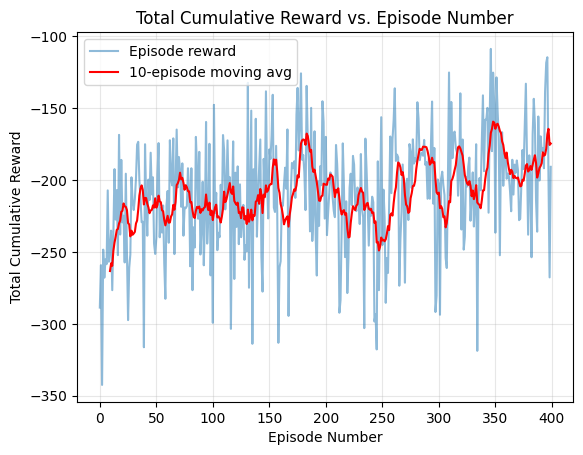

First 10 avg: -263.29
Last 10 avg : -174.63
Std (last 30): 37.00333393387983


In [17]:
# Learning curve
avg = np.convolve(reward_history, np.ones(10) / 10, mode="valid")
# 10-episode moving average

plt.plot(reward_history, alpha=0.5, label="Episode reward")
plt.plot(range(9, len(reward_history)), avg, color="red", label="10-episode moving avg")
plt.title("Total Cumulative Reward vs. Episode Number")
plt.xlabel("Episode Number")
plt.ylabel("Total Cumulative Reward")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("First 10 avg:", np.mean(reward_history[:10]))
print("Last 10 avg :", np.mean(reward_history[-10:]))
print("Std (last 30):", np.std(reward_history[-30:]))

##6. Eval and policy


In [18]:
def evaluate(policy, arrival_rates, episodes=25, steps=60):
    env = Junction(arrival_rates=arrival_rates)
    tot = {"waiting": 0, "queue": 0, "throughput": 0, "congested": 0, "switched": 0}
    for _ in range(episodes):
        s = env.reset()
        for _ in range(steps):
            s, r, info = env.step(policy(s), WEIGHTS)
            for k in tot:
                tot[k] += info[k]
    n = episodes * steps #total steps
    return {"avg_waiting": tot["waiting"] / n, #non moving lane
            "avg_queue": tot["queue"] / n, #avg queue per step
            "throughput": tot["throughput"], #total veh moved in n steps
            "congestion_rate": tot["congested"] / n,
            "switches": tot["switched"]} #phase change count

def learned_policy(agent): #takes state and returns phase
    return lambda s: agent.actions[int(np.argmax(agent._row(s)))]   # greedy, no exploration

def fixed_cycle_policy(green=8, yellow=2):
    cycle = ["A1"] * green + ["A3"] * yellow + ["A2"] * green + ["A4"] * yellow
    t = [0] # step counter
    def policy(s):
        a = cycle[t[0] % len(cycle)]
        t[0] += 1
        return a
    return policy

##7. unseen data
(N-S heavy), QL vs Fixed cycle

In [19]:
UNSEEN_TRAFFIC = {"N": 0.5, "S": 0.45, "E": 0.28, "W": 0.25}
# diff arrival prob for steps in lane

q = evaluate(learned_policy(agent), UNSEEN_TRAFFIC)
# trained agent so greedy (epsilon = 0) no exploration
f = evaluate(fixed_cycle_policy(), UNSEEN_TRAFFIC)
# fixed policy baseline

# Results table
print(f"{'Metric':<25}{'Q-Learning':<15}{'Fixed-Cycle':<15}")
print(f"{'Avg Waiting Time':<25}{q['avg_waiting']:<15.2f}{f['avg_waiting']:<15.2f}")
print(f"{'Avg Queue Length':<25}{q['avg_queue']:<15.2f}{f['avg_queue']:<15.2f}")
print(f"{'Traffic Throughput':<25}{q['throughput']:<15}{f['throughput']:<15}")
print(f"{'Congestion Rate':<25}{q['congestion_rate']*100:<15.2f}{f['congestion_rate']*100:<15.2f}")
print(f"{'Unnecessary Switches':<25}{q['switches']:<15}{f['switches']:<15}")

# % improvement of Q-learning over fixed-cycle
print("\n% Improvement of Q-Learning over Fixed-Cycle")
print(f"Waiting Time: {(f['avg_waiting'] - q['avg_waiting']) / f['avg_waiting'] * 100:+.1f}%")
print(f"Queue Length: {(f['avg_queue'] - q['avg_queue']) / f['avg_queue'] * 100:+.1f}%")
print(f"Throughput:   {(q['throughput'] - f['throughput']) / f['throughput'] * 100:+.1f}%")

Metric                   Q-Learning     Fixed-Cycle    
Avg Waiting Time         3.23           5.59           
Avg Queue Length         3.43           5.96           
Traffic Throughput       2902           2608           
Congestion Rate          0.00           0.00           
Unnecessary Switches     243            275            

% Improvement of Q-Learning over Fixed-Cycle
Waiting Time: +42.2%
Queue Length: +42.5%
Throughput:   +11.3%


QL better than fixed policy 🔥